In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import seaborn as sns

In [3]:
# Load data
OE_detailed = pd.read_parquet(Path("../data/processed/oe_detailed.parquet"))
OE_Activity_prepped = pd.read_parquet(Path("../data/processed/oe_activity_prepped.parquet"))
OE_joined = pd.read_parquet(Path("../data/processed/oe_joined.parquet"))    
product_pick_times = pd.read_csv(Path("../data/processed/product_pick_times.csv"))

# Rename Travel_Distance column to Distance for df OE_detailed
OE_detailed = OE_detailed.rename(columns={'Travel_Distance': 'Distance'})

In [4]:
display(OE_detailed.head(3))

,ActivityCode,UserID,WorkCode,AssignmentID,ProductID,Quantity,Timestamp,LocationID,Prev_Timestamp,Prev_LocationID,...,Prev_Bay,Prev_Level,Prev_Slot,Aisle2,Bay2,Prev_Aisle2,Prev_Bay2,LocKey,PrevLocKey,Distance
0,PickPut,143,30,7717848,49658,160,2025-09-08 12:11:50.830,35192,NaT,<NA>,...,<NA>,<NA>,<NA>,40,19,<NA>,<NA>,40|19|||,<NA>|<NA>|||,NaN
1,PickPut,143,30,7717860,460,50,2025-09-08 12:12:18.127,422,2025-09-08 12:11:50.830,35192,...,19,2,2,40,18,40,19,40|18|||,40|19|||,21.0
2,PickPut,143,30,7717908,460,100,2025-09-08 12:15:46.650,422,2025-09-08 12:12:18.127,422,...,18,2,1,40,18,40,18,40|18|||,40|18|||,0.0


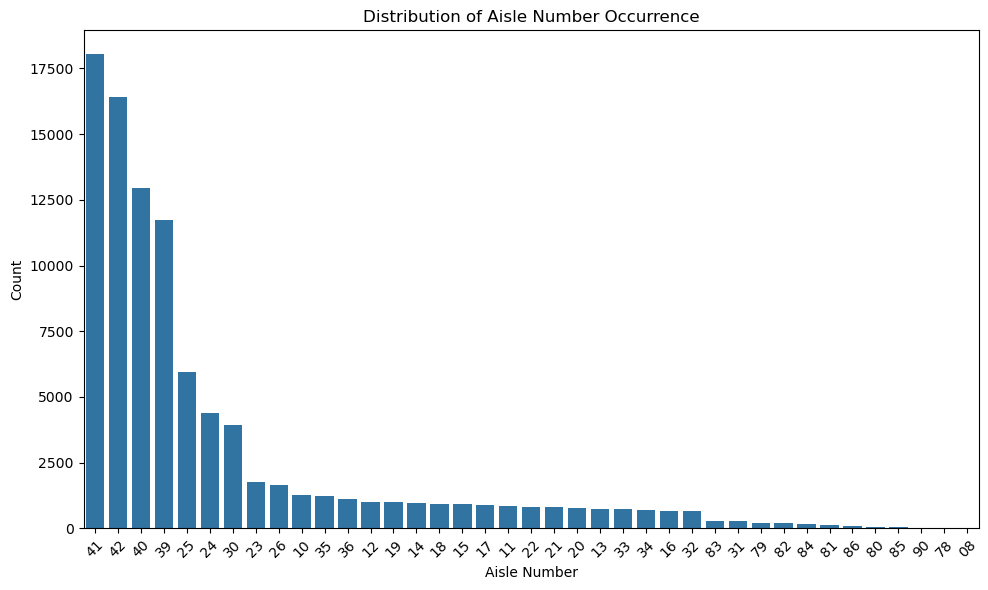

In [6]:
# Plot Distribution of aisle number occurrance
plt.figure(figsize=(10, 6))
sns.countplot(data=OE_detailed, x='Aisle', order=OE_detailed['Aisle'].value_counts().index)
plt.title('Distribution of Aisle Number Occurrence')
plt.xlabel('Aisle Number')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

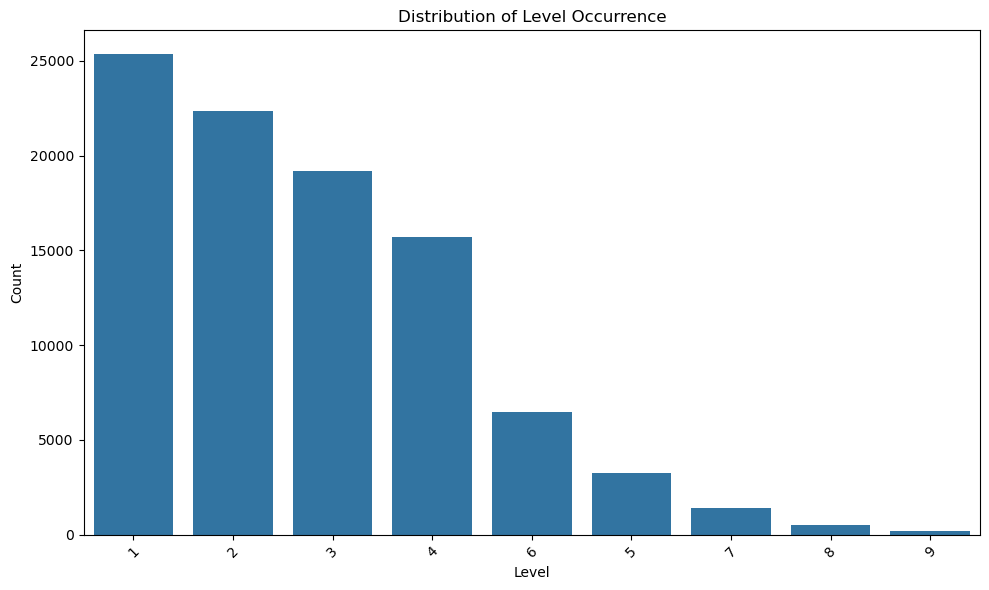

In [7]:
# Distribution of level
plt.figure(figsize=(10, 6))
sns.countplot(data=OE_detailed, x='Level', order=OE_detailed['Level'].value_counts().index)
plt.title('Distribution of Level Occurrence')
plt.xlabel('Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Unique UnitOfMeasure values: ['PK' 'EA' 'BX' 'RO' 'PR' 'BG' 'SL' 'RL' 'CA' 'CT' 'CS' 'KT' 'TR' 'DI'
 'OP' 'VI' 'SP' 'PC' None 'CN' 'DZ' 'TB' 'GR' 'BT' 'ST' 'SH' 'PD' 'GA'
 'EN' 'TY' 'JR']


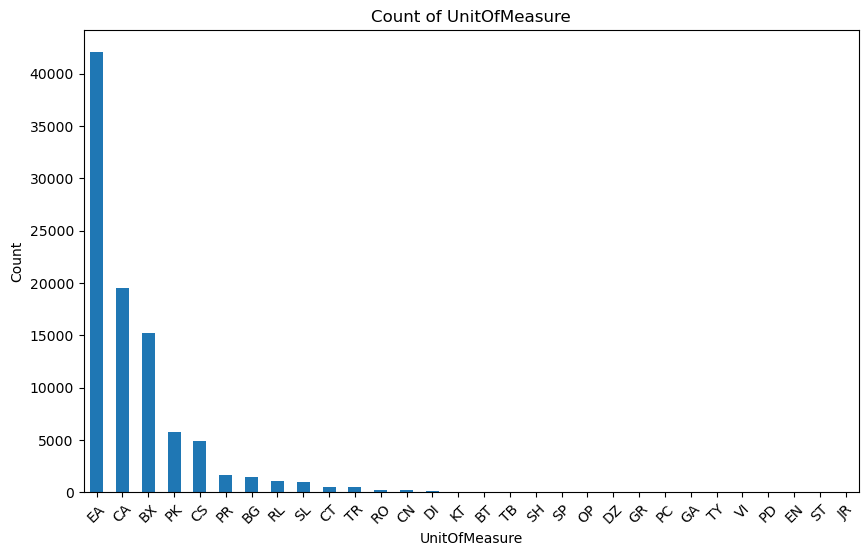

In [14]:
# print different unitof measures in df
print("Unique UnitOfMeasure values:", OE_detailed["UnitOfMeasure"].unique())
# barplot showing count
plt.figure(figsize=(10, 6))
OE_detailed["UnitOfMeasure"].value_counts().plot(kind="bar")
plt.title("Count of UnitOfMeasure")
plt.xlabel("UnitOfMeasure")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Count percentage of product occurring more than 10, 20, 30 times
product_counts = OE_detailed['ProductID'].value_counts()
print("Percentage of products occurring more than 10 times:", (product_counts > 10).mean())
print("Percentage of products occurring more than 20 times:", (product_counts > 20).mean())
print("Percentage of products occurring more than 30 times:", (product_counts > 30).mean())
# how much of the data is covered by products occurring more than 10, 20, 30 times
print("Percentage of data covered by products occurring more than 10 times:", (OE_detailed['ProductID'].isin(product_counts[product_counts > 10].index)).mean())
print("Percentage of data covered by products occurring more than 20 times:", (OE_detailed['ProductID'].isin(product_counts[product_counts > 20].index)).mean())
print("Percentage of data covered by products occurring more than 30 times:", (OE_detailed['ProductID'].isin(product_counts[product_counts > 30].index)).mean())

Percentage of products occurring more than 10 times: 0.2103434451423226
Percentage of products occurring more than 20 times: 0.1274889750100227
Percentage of products occurring more than 30 times: 0.09007082720833891
Percentage of data covered by products occurring more than 10 times: 0.8184466430795958
Percentage of data covered by products occurring more than 20 times: 0.7208851507383318
Percentage of data covered by products occurring more than 30 times: 0.6475604330416729


In [21]:
# Percentage of total rows that are in the top 100 most common products
top_100_products = product_counts.head(100).index
percentage_top_100 = (OE_detailed['ProductID'].isin(top_100_products)).mean()
print("Percentage of data covered by top 100 most common products:", percentage_top_100)

Percentage of data covered by top 100 most common products: 0.27546026567233745
